# 🥁 Drum OMR — MobileNetV3 Training

This notebook trains a model to read drum scores from bar images.

**What it learns:** Given a cropped image of one bar of drum notation,
output which drums are hit at each 16th-note position.

**Architecture:** MobileNetV3-Small (pretrained on ImageNet) + custom head

**Output:** 16 beat positions × 12 drums = 192 binary values per bar

---
**Before running:** Upload `dataset.zip` to `MyDrive/drumhub/` in Google Drive.
Run `python ml/omr/prepare_upload.py` locally to create the zip.

In [1]:
# ── 1. Install extra deps (torch/torchvision already on Colab) ────────────────
!pip install onnx onnxruntime onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 11.2 MB/s eta 0:00:00


In [2]:
# ── 2. Mount Google Drive and unzip dataset ───────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

DRIVE_ROOT = '/content/drive/MyDrive/drumhub'
ZIP_PATH   = f'{DRIVE_ROOT}/dataset.zip'
DATA_ROOT  = '/content/dataset'
CKPT_DIR   = f'{DRIVE_ROOT}/checkpoints'

os.makedirs(CKPT_DIR, exist_ok=True)

if not os.path.exists(DATA_ROOT):
    print('Unzipping dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content')
    print('Done.')
else:
    print('Dataset already extracted.')

IMG_DIR = f'{DATA_ROOT}/images'
LBL_DIR = f'{DATA_ROOT}/labels'
print(f'Images: {len(os.listdir(IMG_DIR))}  Labels: {len(os.listdir(LBL_DIR))}')

Mounted at /content/drive
Unzipping dataset...
Done.
Images: 6416  Labels: 6416


In [3]:
# ── 3. Config ─────────────────────────────────────────────────────────────────
import torch

# 16th-note grid: beat positions in 4/4 (1.0, 1.25, 1.5 ... 4.75)
BEAT_GRID = [round(1 + i * 0.25, 2) for i in range(16)]

# 16 drum types in order — defines the output columns
DRUMS = [
    'hi_hat_closed', 'snare', 'kick',
    'ride', 'crash', 'hi_hat_open',
    'floor_tom_1', 'floor_tom_2', 'tom_hi', 'hi_hat_pedal',
    'tom_mid', 'ride_bell', 'snare_rim',
    'china', 'splash', 'clap',
]
DRUM_IDX = {d: i for i, d in enumerate(DRUMS)}

N_BEATS  = len(BEAT_GRID)   # 16
N_DRUMS  = len(DRUMS)       # 12
N_OUT    = N_BEATS * N_DRUMS  # 192

IMG_H, IMG_W = 128, 384     # height x width fed to the model
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 3e-4
THRESHOLD    = 0.5          # sigmoid output > this → drum is hit

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}  |  Output size: {N_OUT} ({N_BEATS} beats × {N_DRUMS} drums)')

Device: cuda  |  Output size: 192 (16 beats × 12 drums)


In [4]:
# ── 4. Dataset class ──────────────────────────────────────────────────────────
# Each sample = one bar image + a (192,) binary target vector.
#
# The target vector is built like this:
#   target[beat_idx * N_DRUMS + drum_idx] = 1  if that drum is hit at that beat
#
# beat_idx = index into BEAT_GRID (0=beat1, 4=beat2, 8=beat3, 12=beat4)
# drum_idx = index into DRUMS

import json
import numpy as np
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T


def label_to_target(label_path: str) -> torch.Tensor:
    """Convert a label JSON file into a flat (192,) binary tensor."""
    data = json.loads(Path(label_path).read_text())
    target = torch.zeros(N_BEATS, N_DRUMS)

    for beat_entry in data.get('beats', []):
        if beat_entry.get('rest'):
            continue
        beat_val = float(beat_entry['beat'])

        # Find closest 16th-note grid position
        dists = [abs(beat_val - g) for g in BEAT_GRID]
        beat_idx = int(np.argmin(dists))
        if min(dists) > 0.13:      # too far from grid (e.g. triplets) — skip for now
            continue

        for drum in beat_entry.get('drums', []):
            base_drum = drum.replace('_ghost', '')
            if base_drum in DRUM_IDX:
                target[beat_idx, DRUM_IDX[base_drum]] = 1.0

    return target.flatten()  # shape (192,)


class DrumBarDataset(Dataset):
    def __init__(self, image_paths: list, label_paths: list, augment: bool = False):
        self.images  = image_paths
        self.labels  = label_paths
        self.augment = augment

        # Base transforms: resize → 3-channel → ImageNet normalise
        base = [
            T.Resize((IMG_H, IMG_W)),
            T.Grayscale(num_output_channels=3),  # MobileNet expects RGB
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ]

        # Augmentation: simulate photos taken at an angle / different light
        aug = [
            T.Resize((IMG_H, IMG_W)),
            T.Grayscale(num_output_channels=3),
            T.RandomAffine(degrees=2, translate=(0, 0.04)),  # slight tilt/shift
            T.ColorJitter(brightness=0.4, contrast=0.4),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ]

        self.transform = T.Compose(aug if augment else base)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img    = Image.open(self.images[idx]).convert('L')  # grayscale
        x      = self.transform(img)
        y      = label_to_target(self.labels[idx])
        return x, y

print('Dataset class defined.')

Dataset class defined.


In [5]:
# ── 5. Train / val / test split (by song, not by bar) ────────────────────────
# Splitting by bar would leak information — the model would see other bars from
# the same song during training, making eval artificially easy.
# Instead we split by song name so held-out songs are completely unseen.

import random
from collections import defaultdict

random.seed(42)

img_files = sorted(Path(IMG_DIR).glob('*.png'))
lbl_files = {p.stem: str(p) for p in Path(LBL_DIR).glob('*.json')}

# Group bars by song name (everything before '_bar')
songs = defaultdict(list)
for img in img_files:
    stem = img.stem
    song = stem[:stem.rfind('_bar')]
    if stem in lbl_files:
        songs[song].append((str(img), lbl_files[stem]))

song_names = list(songs.keys())
random.shuffle(song_names)

n_val  = max(1, int(len(song_names) * 0.10))
n_test = max(1, int(len(song_names) * 0.10))

test_songs  = set(song_names[:n_test])
val_songs   = set(song_names[n_test:n_test + n_val])
train_songs = set(song_names[n_test + n_val:])

def collect(song_set):
    imgs, lbls = [], []
    for s in song_set:
        for img, lbl in songs[s]:
            imgs.append(img)
            lbls.append(lbl)
    return imgs, lbls

train_imgs, train_lbls = collect(train_songs)
val_imgs,   val_lbls   = collect(val_songs)
test_imgs,  test_lbls  = collect(test_songs)

print(f'Songs  — train: {len(train_songs)}  val: {len(val_songs)}  test: {len(test_songs)}')
print(f'Bars   — train: {len(train_imgs)}   val: {len(val_imgs)}   test: {len(test_imgs)}')

Songs  — train: 136  val: 17  test: 17
Bars   — train: 5310   val: 417   test: 689


In [6]:
# ── 6. Data loaders ───────────────────────────────────────────────────────────
from torch.utils.data import DataLoader

train_ds = DrumBarDataset(train_imgs, train_lbls, augment=True)
val_ds   = DrumBarDataset(val_imgs,   val_lbls,   augment=False)
test_ds  = DrumBarDataset(test_imgs,  test_lbls,  augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check: show one batch
x, y = next(iter(train_dl))
print(f'Batch — images: {x.shape}  targets: {y.shape}  active cells: {y.sum().item():.0f}')

Batch — images: torch.Size([32, 3, 128, 384])  targets: torch.Size([32, 192])  active cells: 297


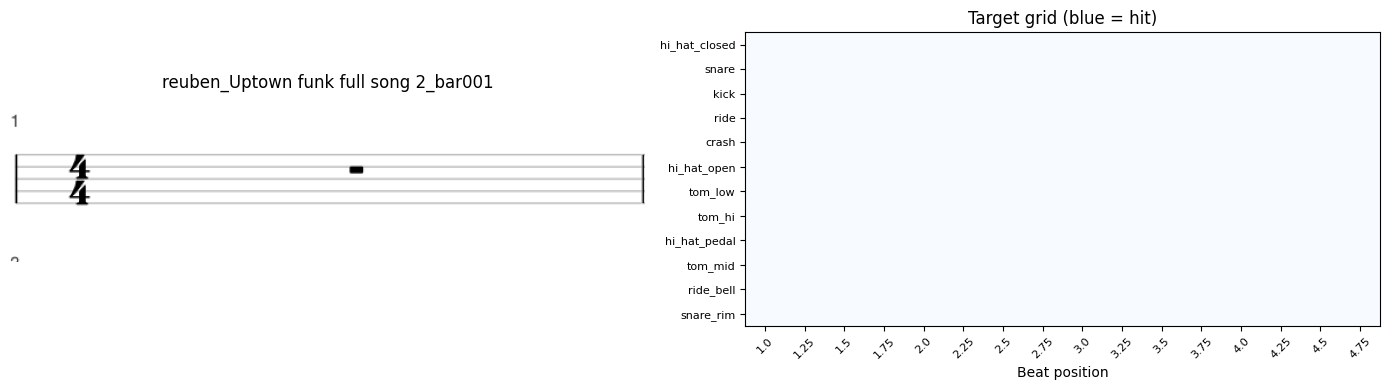

In [7]:
# ── 7. Visualise one sample ───────────────────────────────────────────────────
# Look at an image and its target grid before training.
import matplotlib.pyplot as plt

img_raw = Image.open(train_imgs[0]).convert('L')
target  = label_to_target(train_lbls[0]).reshape(N_BEATS, N_DRUMS).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.imshow(img_raw, cmap='gray')
ax1.set_title(Path(train_imgs[0]).stem)
ax1.axis('off')

ax2.imshow(target.T, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax2.set_xticks(range(N_BEATS))
ax2.set_xticklabels([str(b) for b in BEAT_GRID], rotation=45, fontsize=8)
ax2.set_yticks(range(N_DRUMS))
ax2.set_yticklabels(DRUMS, fontsize=8)
ax2.set_title('Target grid (blue = hit)')
ax2.set_xlabel('Beat position')

plt.tight_layout()
plt.show()

In [8]:
# ── 8. Model ──────────────────────────────────────────────────────────────────
# MobileNetV3-Small pretrained on ImageNet.
#
# Why MobileNetV3?
#   - Small & fast → runs on M1 via ONNX
#   - Pretrained feature extractor — already knows edges, shapes, textures
#   - We freeze early layers and only fine-tune the head on our drum data
#
# Architecture:
#   Image (3×128×384)
#     → MobileNetV3 backbone → global avg pool → (576,)
#     → Dropout(0.2)
#     → Linear(576→1024) → Hardswish
#     → Dropout(0.2)
#     → Linear(1024→192)   ← our new head
#   Output: (192,) logits → sigmoid → probabilities

import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

def build_model() -> nn.Module:
    model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)

    # Replace only the final classification Linear — keep the rest of the head
    in_features = model.classifier[-1].in_features  # 1024
    model.classifier[-1] = nn.Linear(in_features, N_OUT)

    # Freeze backbone (features), only train classifier head
    for param in model.features.parameters():
        param.requires_grad = False

    return model

model = build_model().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parameters — total: {total:,}  trainable: {trainable:,}  frozen: {total - trainable:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 130MB/s]

Parameters — total: 1,714,656  trainable: 787,648  frozen: 927,008


In [9]:
# ── 9. Training loop ──────────────────────────────────────────────────────────
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

all_targets = torch.stack([label_to_target(l) for l in train_lbls])
pos  = all_targets.sum(0).clamp(min=1)
neg  = (len(train_lbls) - all_targets.sum(0)).clamp(min=1)
pos_weight = (neg / pos).to(DEVICE)
print(f'pos_weight range: {pos_weight.min():.1f} – {pos_weight.max():.1f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


def run_epoch(loader, train: bool, opt=None):
    # opt: pass the current optimizer so phase 2 can use optimizer2 instead of optimizer
    if opt is None:
        opt = optimizer
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)

            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()

            total_loss += loss.item() * x.size(0)
            preds   = (logits.sigmoid() > THRESHOLD).float()
            correct += (preds == y).all(dim=1).sum().item()
            total   += x.size(0)

    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
CKPT_PATH = f'{CKPT_DIR}/omr_best.pt'

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    va_loss, va_acc = run_epoch(val_dl,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), CKPT_PATH)
        saved = ' ← saved'
    else:
        saved = ''

    print(f'Epoch {epoch:2d}/{EPOCHS}  '
          f'train loss={tr_loss:.4f} acc={tr_acc:.3f}  '
          f'val loss={va_loss:.4f} acc={va_acc:.3f}{saved}')

pos_weight range: 0.8 – 5310.0
Epoch  1/30  train loss=1.1398 acc=0.000  val loss=0.7508 acc=0.000 ← saved
Epoch  2/30  train loss=0.8435 acc=0.010  val loss=0.6123 acc=0.000 ← saved
Epoch  3/30  train loss=0.7484 acc=0.035  val loss=0.5622 acc=0.024 ← saved
Epoch  4/30  train loss=0.6426 acc=0.043  val loss=0.4482 acc=0.089 ← saved
Epoch  5/30  train loss=0.5964 acc=0.067  val loss=0.4119 acc=0.041 ← saved
Epoch  6/30  train loss=0.5720 acc=0.063  val loss=0.4027 acc=0.134 ← saved
Epoch  7/30  train loss=0.5372 acc=0.093  val loss=0.4103 acc=0.058
Epoch  8/30  train loss=0.5270 acc=0.112  val loss=0.3824 acc=0.230 ← saved
Epoch  9/30  train loss=0.5088 acc=0.123  val loss=0.3857 acc=0.230
Epoch 10/30  train loss=0.4947 acc=0.117  val loss=0.3905 acc=0.221
Epoch 11/30  train loss=0.4883 acc=0.136  val loss=0.3913 acc=0.218
Epoch 12/30  train loss=0.4729 acc=0.125  val loss=0.3917 acc=0.249
Epoch 13/30  train loss=0.4677 acc=0.143  val loss=0.4027 acc=0.225
Epoch 14/30  train loss=0.448

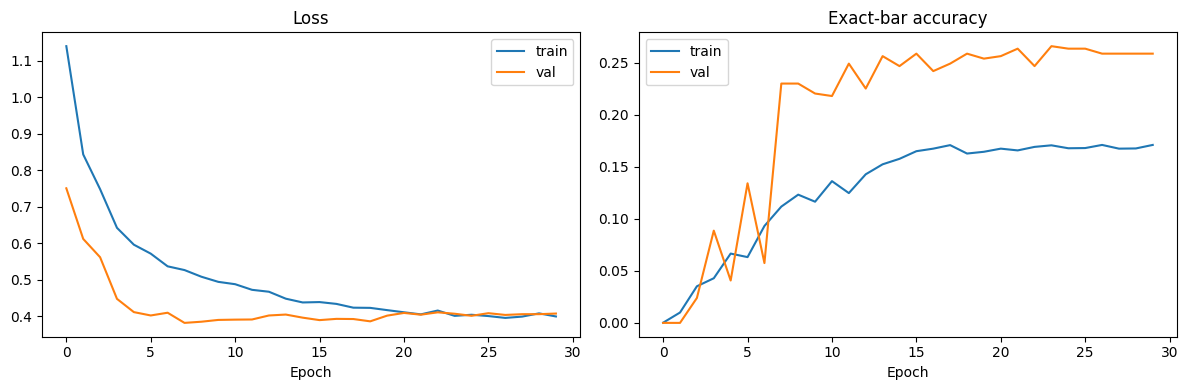

In [10]:
# ── 10. Plot training curves ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='train')
ax1.plot(history['val_loss'],   label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history['train_acc'], label='train')
ax2.plot(history['val_acc'],   label='val')
ax2.set_title('Exact-bar accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
# ── 11. Evaluate on held-out test set ─────────────────────────────────────────
from sklearn.metrics import f1_score

model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_preds, all_gts = [], []

with torch.no_grad():
    for x, y in test_dl:
        logits = model(x.to(DEVICE))
        preds  = (logits.sigmoid() > THRESHOLD).cpu().float()
        all_preds.append(preds)
        all_gts.append(y)

P  = torch.cat(all_preds).numpy()   # (N_test, 192)
GT = torch.cat(all_gts).numpy()     # (N_test, 192)

exact_acc = (P == GT).all(axis=1).mean()
cell_acc  = (P == GT).mean()

print(f'Test exact-bar accuracy : {exact_acc:.3f} ({exact_acc*100:.1f}%)')
print(f'Test cell accuracy      : {cell_acc:.3f} ({cell_acc*100:.1f}%)')
print()

P_drums  = P.reshape(-1, N_BEATS, N_DRUMS).max(axis=1)
GT_drums = GT.reshape(-1, N_BEATS, N_DRUMS).max(axis=1)

print(f'{"Drum":<18} {"F1":>6}')
print('-' * 26)
for i, drum in enumerate(DRUMS):
    f1 = f1_score(GT_drums[:, i], P_drums[:, i], zero_division=0)
    print(f'{drum:<18} {f1:6.3f}')

Test exact-bar accuracy : 0.289 (28.9%)
Test cell accuracy      : 0.920 (92.0%)

Drum                   F1
--------------------------
hi_hat_closed       0.864
snare               0.938
kick                0.902
ride                0.251
crash               0.366
hi_hat_open         0.370
tom_low             0.701
tom_hi              0.721
hi_hat_pedal        0.314
tom_mid             0.239
ride_bell           0.276
snare_rim           0.171


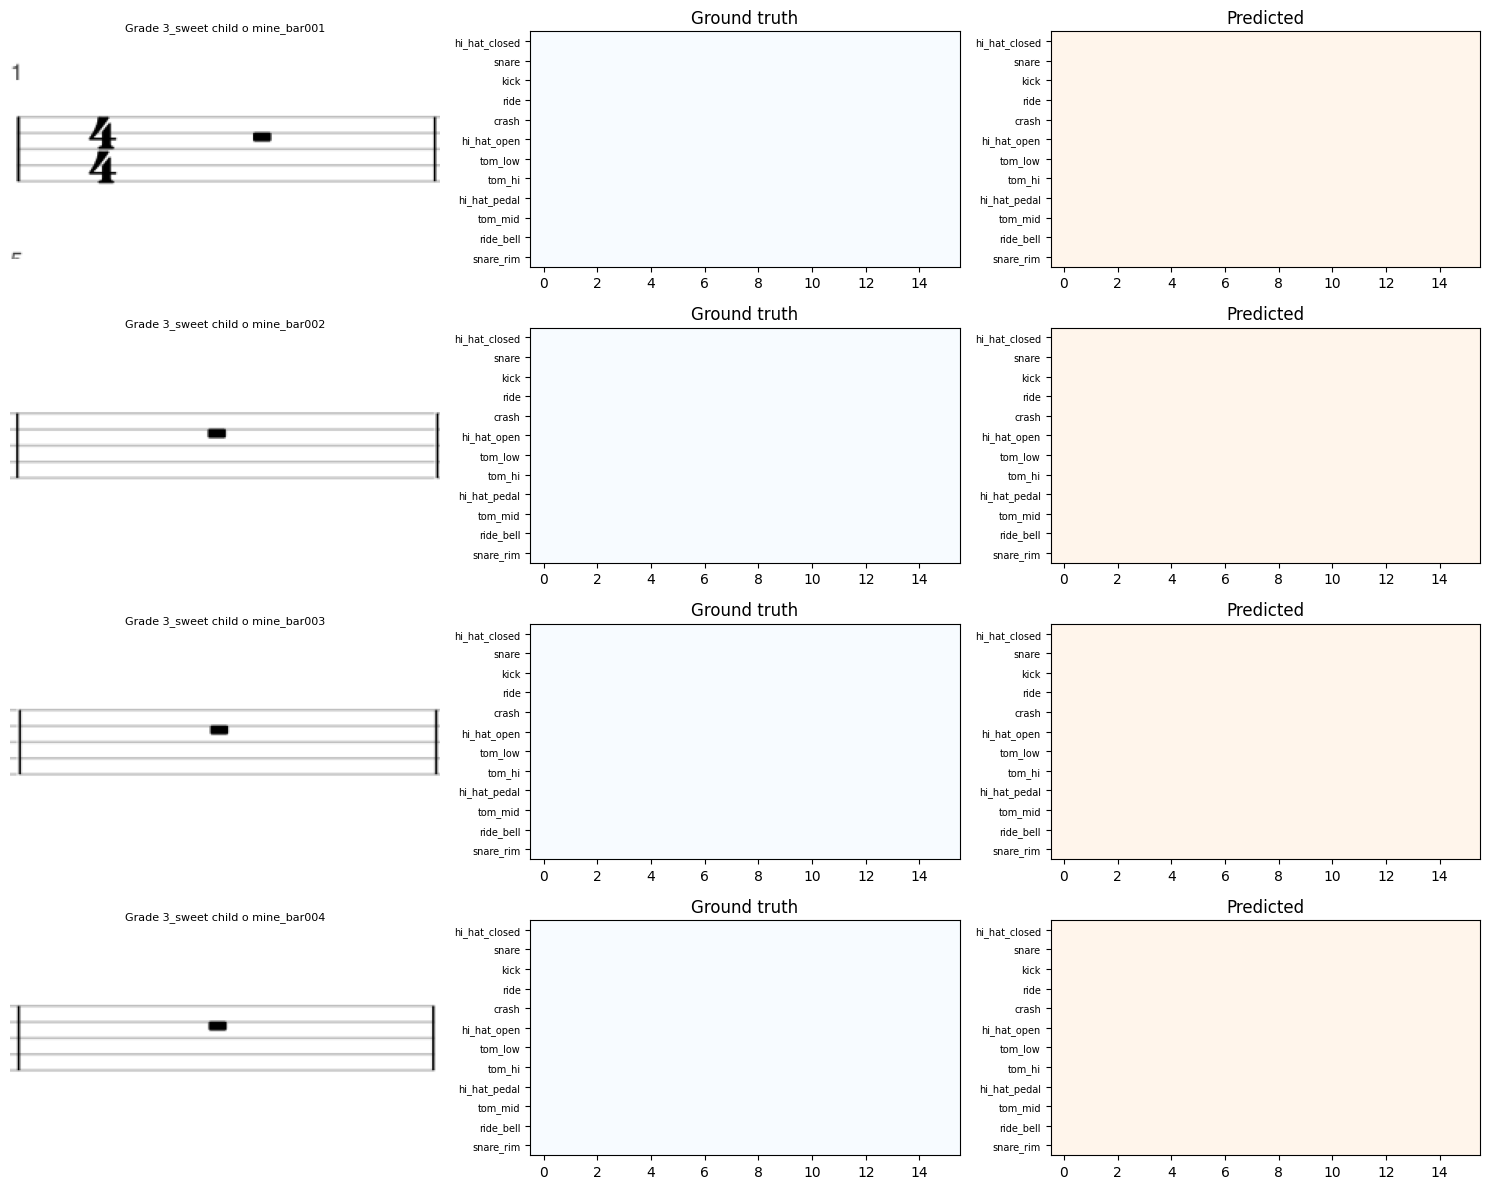

In [12]:
# ── 12. Visualise predictions ─────────────────────────────────────────────────
# Side-by-side: the bar image, the ground truth grid, the predicted grid.

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(15, n_show * 3))

model.eval()
with torch.no_grad():
    for i in range(n_show):
        img_path = test_imgs[i]
        lbl_path = test_lbls[i]

        img_raw = Image.open(img_path).convert('L')
        x, y    = test_ds[i]
        logits  = model(x.unsqueeze(0).to(DEVICE))
        pred    = (logits.sigmoid() > THRESHOLD).cpu().float().reshape(N_BEATS, N_DRUMS)
        truth   = y.reshape(N_BEATS, N_DRUMS)

        axes[i, 0].imshow(img_raw, cmap='gray'); axes[i, 0].axis('off')
        axes[i, 0].set_title(Path(img_path).stem[:40], fontsize=8)

        axes[i, 1].imshow(truth.numpy().T, aspect='auto', cmap='Blues', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground truth')
        axes[i, 1].set_yticks(range(N_DRUMS)); axes[i, 1].set_yticklabels(DRUMS, fontsize=7)

        axes[i, 2].imshow(pred.numpy().T,  aspect='auto', cmap='Oranges', vmin=0, vmax=1)
        axes[i, 2].set_title('Predicted')
        axes[i, 2].set_yticks(range(N_DRUMS)); axes[i, 2].set_yticklabels(DRUMS, fontsize=7)

plt.tight_layout()
plt.show()

In [13]:
# ── 13. Unfreeze backbone and fine-tune everything ────────────────────────────
# Phase 1 (cells 8-9) trained only the classifier head with the backbone frozen.
# Now we unfreeze all layers and continue at 10× lower LR.
# This lets the backbone adapt its features to drum notation specifically.
#
# We start from the best Phase 1 checkpoint, not the final epoch weights.

# Load best Phase 1 weights before unfreezing
model.load_state_dict(torch.load(CKPT_PATH))

for param in model.parameters():
    param.requires_grad = True

trainable2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'All {trainable2:,} parameters now trainable')

FINETUNE_EPOCHS = 15
CKPT_PATH_FT    = f'{CKPT_DIR}/omr_finetuned.pt'

optimizer2 = AdamW(model.parameters(), lr=LR / 10, weight_decay=1e-4)
scheduler2 = CosineAnnealingLR(optimizer2, T_max=FINETUNE_EPOCHS)

best_ft_loss = float('inf')

for epoch in range(1, FINETUNE_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, train=True,  opt=optimizer2)
    va_loss, va_acc = run_epoch(val_dl,   train=False)
    scheduler2.step()

    if va_loss < best_ft_loss:
        best_ft_loss = va_loss
        torch.save(model.state_dict(), CKPT_PATH_FT)
        saved = ' ← saved'
    else:
        saved = ''

    print(f'Finetune {epoch:2d}/{FINETUNE_EPOCHS}  '
          f'train loss={tr_loss:.4f} acc={tr_acc:.3f}  '
          f'val loss={va_loss:.4f} acc={va_acc:.3f}{saved}')

# Point subsequent cells at the finetuned checkpoint
CKPT_PATH = CKPT_PATH_FT
print(f'\nBest finetuned model: {CKPT_PATH}')

All 1,714,656 parameters now trainable
Finetune  1/15  train loss=0.4722 acc=0.157  val loss=0.3529 acc=0.252 ← saved
Finetune  2/15  train loss=0.4307 acc=0.167  val loss=0.3451 acc=0.240 ← saved
Finetune  3/15  train loss=0.4086 acc=0.173  val loss=0.3093 acc=0.245 ← saved
Finetune  4/15  train loss=0.3905 acc=0.180  val loss=0.3063 acc=0.252 ← saved
Finetune  5/15  train loss=0.3758 acc=0.182  val loss=0.2977 acc=0.235 ← saved
Finetune  6/15  train loss=0.3618 acc=0.186  val loss=0.2921 acc=0.235 ← saved
Finetune  7/15  train loss=0.3590 acc=0.185  val loss=0.2850 acc=0.245 ← saved
Finetune  8/15  train loss=0.3510 acc=0.187  val loss=0.2769 acc=0.235 ← saved
Finetune  9/15  train loss=0.3399 acc=0.191  val loss=0.2769 acc=0.254
Finetune 10/15  train loss=0.3384 acc=0.191  val loss=0.2761 acc=0.237 ← saved
Finetune 11/15  train loss=0.3372 acc=0.191  val loss=0.2731 acc=0.252 ← saved
Finetune 12/15  train loss=0.3261 acc=0.192  val loss=0.2728 acc=0.252 ← saved
Finetune 13/15  train

In [14]:
# ── 13b. Re-evaluate finetuned model ─────────────────────────────────────────
from sklearn.metrics import f1_score

model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_preds, all_gts = [], []

with torch.no_grad():
    for x, y in test_dl:
        logits = model(x.to(DEVICE))
        preds  = (logits.sigmoid() > THRESHOLD).cpu().float()
        all_preds.append(preds)
        all_gts.append(y)

P  = torch.cat(all_preds).numpy()
GT = torch.cat(all_gts).numpy()

exact_acc = (P == GT).all(axis=1).mean()
cell_acc  = (P == GT).mean()

print(f'Test exact-bar accuracy : {exact_acc:.3f} ({exact_acc*100:.1f}%)')
print(f'Test cell accuracy      : {cell_acc:.3f} ({cell_acc*100:.1f}%)')
print()

P_drums  = P.reshape(-1, N_BEATS, N_DRUMS).max(axis=1)
GT_drums = GT.reshape(-1, N_BEATS, N_DRUMS).max(axis=1)

print(f'{"Drum":<18} {"F1":>6}')
print('-' * 26)
for i, drum in enumerate(DRUMS):
    f1 = f1_score(GT_drums[:, i], P_drums[:, i], zero_division=0)
    print(f'{drum:<18} {f1:6.3f}')

Test exact-bar accuracy : 0.305 (30.5%)
Test cell accuracy      : 0.943 (94.3%)

Drum                   F1
--------------------------
hi_hat_closed       0.884
snare               0.942
kick                0.918
ride                0.644
crash               0.475
hi_hat_open         0.574
tom_low             0.712
tom_hi              0.761
hi_hat_pedal        0.565
tom_mid             0.224
ride_bell           0.508
snare_rim           0.229


In [15]:
# ── 14. Export to ONNX ────────────────────────────────────────────────────────
import onnx
import onnxruntime as ort

ONNX_PATH = f'{CKPT_DIR}/omr.onnx'

model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

dummy_input = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=18,   # 18 matches what Colab's PyTorch actually implements
)

sess    = ort.InferenceSession(ONNX_PATH)
dummy_np = dummy_input.cpu().numpy()
ort_out  = sess.run(None, {'image': dummy_np})[0]
pt_out   = model(dummy_input).detach().cpu().numpy()

max_diff = abs(ort_out - pt_out).max()
print(f'ONNX exported to: {ONNX_PATH}')
print(f'Max output difference PyTorch vs ONNX: {max_diff:.2e}')

/tmp/ipykernel_3300/4007512648.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX exported to: /content/drive/MyDrive/drumhub/checkpoints/omr.onnx
Max output difference PyTorch vs ONNX: 1.83e-04


In [16]:
# ── 15. Decode ONNX output back to JSON ───────────────────────────────────────
# This is the function you'll call in Electron / FastAPI:
#   image → ONNX inference → JSON label

import torchvision.transforms as transforms  # explicit import — avoids collision with T variable

def predict_bar(image_path: str) -> dict:
    """Run ONNX inference on one bar image, return label-format dict."""
    transform = transforms.Compose([
        transforms.Resize((IMG_H, IMG_W)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img    = Image.open(image_path).convert('L')
    x      = transform(img).unsqueeze(0).numpy()   # (1, 3, H, W)
    logits = sess.run(None, {'image': x})[0]        # (1, 192)
    probs  = 1 / (1 + np.exp(-logits[0]))           # sigmoid
    grid   = (probs > THRESHOLD).reshape(N_BEATS, N_DRUMS)

    beats = []
    for bi, beat_val in enumerate(BEAT_GRID):
        drums = [DRUMS[di] for di in range(N_DRUMS) if grid[bi, di]]
        if drums:
            beats.append({'beat': str(beat_val), 'drums': drums})

    return {'time_signature': '4/4', 'beats': beats}


# Test it on a sample
result = predict_bar(test_imgs[0])
print(json.dumps(result, indent=2))

{
  "time_signature": "4/4",
  "beats": []
}


## Next steps

1. Download `omr.onnx` from Drive to your M1
2. Load it in FastAPI: `onnxruntime.InferenceSession('omr.onnx')`
3. Electron sends a bar image → FastAPI runs inference → returns JSON → VexFlow renders it
4. Once the baseline works, unfreeze the backbone (Cell 13) for a second training pass
5. For tuplets / 32nd notes: extend `BEAT_GRID` to 32 positions and retrain